# Sistema de Recomendação de Produtos Financeiros
## Abordagem: Logistic Regression + Causal Inference (Position Debiasing) + Epsilon-Greedy

---

### Visão Geral do Pipeline

| Etapa | Descrição |
|-------|-----------|
| **1. EDA** | Análise exploratória com foco no viés de posição no carrossel |
| **2. Feature Engineering** | Features temporais sem data leakage (janela deslizante de 6 meses) |
| **3. Split Temporal** | Treino até Set/2025; teste Out–Dez/2025 (~12% dos dados) |
| **4. Modelagem** | Um modelo de Regressão Logística por produto (17 modelos treinados) |
| **5. Causal Inference** | Debias de posição fixando `posicao_exibicao=1` na inferência (do-calculus de Pearl) |
| **6. Epsilon-Greedy** | 10% de exploração nas posições 6–20 para diversificar dados de retreino |
| **7. Avaliação** | NDCG@5, Precision@5, Hit Rate@5, AUC-ROC vs. baselines (Popularidade e Aleatório) |

### Motivação da Abordagem por Produto

Modelos únicos para todos os produtos diluem os padrões específicos de cada produto (ex.: perfil de crédito vs. investimento). Um modelo por produto permite que cada regressor aprenda os preditores mais relevantes para aquele produto, sem interferência cruzada, e que o `class_weight='balanced'` compense o desbalanceamento individualmente.

## 0. Setup e Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings, json, pickle
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Setup concluido.')

Setup concluido.


## 1. Carregamento dos Dados

O dataset contém quatro tabelas relacionadas por `id_cliente` e `produto`:

| Tabela | Descrição | Dimensões |
|--------|-----------|-----------|
| `clientes.csv` | Perfil financeiro, demográfico e comportamental de cada cliente | 50.000 × 23 |
| `interacoes.csv` | Log de exibições no carrossel: impressões, cliques e contratos por safra | ~503k × 10 |
| `contratos_ativos.csv` | Produtos atualmente ativos por cliente (usado para excluir do ranking) | ~62k × 5 |
| `produtos.csv` | Metadados dos 20 produtos disponíveis (categoria, receita_media, margem) | 20 × 6 |

As interações cobrem **Jan/2024 a Dez/2025**, identificadas por `safra` (formato YYYYMM). A coluna `posicao_exibicao` (1–20) indica a posição do produto no carrossel, variável central para o problema de viés.

In [2]:
DATA_PATH = 'data'  # ajuste para o path local

clientes   = pd.read_csv(f'{DATA_PATH}/clientes.csv')
interacoes = pd.read_csv(f'{DATA_PATH}/interacoes.csv', parse_dates=['timestamp'])
contratos  = pd.read_csv(f'{DATA_PATH}/contratos_ativos.csv', parse_dates=['data_contratacao'])
produtos   = pd.read_csv(f'{DATA_PATH}/produtos.csv')

print(f'Clientes:   {clientes.shape}')
print(f'Interacoes: {interacoes.shape}')
print(f'Contratos:  {contratos.shape}')
print(f'Produtos:   {produtos.shape}')
clientes.head(3)

Clientes:   (50000, 23)
Interacoes: (503292, 10)
Contratos:  (61997, 5)
Produtos:   (20, 6)


,id_cliente,idade,genero,uf,segmento,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,...,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite,canal_preferencial
0,1,34,F,PR,basico,617.21,1500.00,2981.16,17,0,...,97.96,139.06,38.89,35.88,114.53,1,12.0,725.95,0.2062,agencia
1,2,58,F,SP,premium,700.98,16620.77,41901.11,21,8,...,705.43,679.74,487.83,147.66,415.77,0,6.0,14116.66,0.1795,web
2,3,46,F,AM,intermediario,696.96,4202.55,916.78,57,2,...,795.14,239.72,69.56,245.75,357.10,1,8.0,4414.47,0.4499,app


## 2. Análise Exploratória dos Dados (EDA)

### 2.1 Distribuição de Clientes por Segmento

A base de clientes está dividida em três segmentos (`basico`, `intermediario`, `premium`) com perfis financeiros distintos. Exploramos a distribuição de idade e renda para entender o público-alvo e verificar se as features de perfil têm variância suficiente para ser úteis nos modelos.

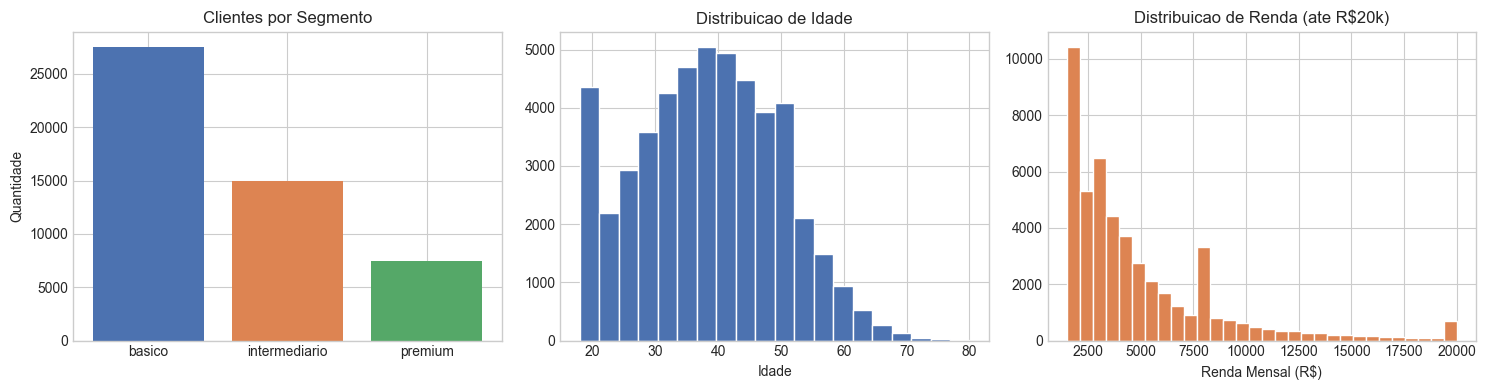

               score_credito  renda_mensal  saldo_medio_conta
segmento                                                     
basico                449.41       2816.43            4359.66
intermediario         600.52       5368.84            8320.36
premium               779.30      11935.17           18139.43


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

seg = clientes['segmento'].value_counts()
axes[0].bar(seg.index, seg.values, color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Clientes por Segmento')
axes[0].set_ylabel('Quantidade')

axes[1].hist(clientes['idade'], bins=20, color='#4C72B0', edgecolor='white')
axes[1].set_title('Distribuicao de Idade')
axes[1].set_xlabel('Idade')

axes[2].hist(clientes['renda_mensal'].clip(upper=20000), bins=30, color='#DD8452', edgecolor='white')
axes[2].set_title('Distribuicao de Renda (ate R$20k)')
axes[2].set_xlabel('Renda Mensal (R$)')

plt.tight_layout()
plt.show()

print(clientes[['segmento','score_credito','renda_mensal','saldo_medio_conta']].groupby('segmento').mean().round(2))

### 2.2 Vies de Posicao no Carrossel

**Este e o achado mais importante do EDA e a motivacao principal para Causal Inference.**

A taxa de conversao cai drasticamente com a posicao de exibicao. Sem controlar esse efeito,
o modelo aprenderia que 'estar na posicao 1 causa contratacao' — um loop vicioso que perpetuaria
a politica de exibicao estatica atual em vez de aprender preferencias reais dos clientes.

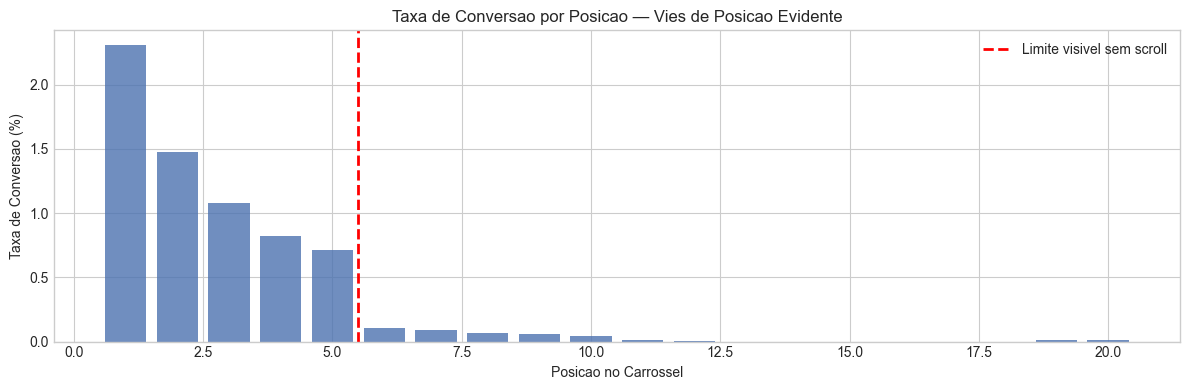

Conversao posicao 1:  2.308%
Conversao posicao 10: 0.042%
Conversao posicao 20: 0.012%


In [4]:
pos_agg = interacoes.groupby('posicao_exibicao').agg(
    n=('id_interacao','count'),
    contratos=('contratou','sum')
).reset_index()
pos_agg['conversion_rate'] = pos_agg['contratos'] / pos_agg['n']

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(pos_agg['posicao_exibicao'], pos_agg['conversion_rate'] * 100, color='#4C72B0', alpha=0.8)
ax.axvline(5.5, color='red', linestyle='--', linewidth=2, label='Limite visivel sem scroll')
ax.set_xlabel('Posicao no Carrossel')
ax.set_ylabel('Taxa de Conversao (%)')
ax.set_title('Taxa de Conversao por Posicao — Vies de Posicao Evidente')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Conversao posicao 1:  {pos_agg.loc[pos_agg.posicao_exibicao==1, 'conversion_rate'].values[0]:.3%}")
print(f"Conversao posicao 10: {pos_agg.loc[pos_agg.posicao_exibicao==10, 'conversion_rate'].values[0]:.3%}")
print(f"Conversao posicao 20: {pos_agg.loc[pos_agg.posicao_exibicao==20, 'conversion_rate'].values[0]:.3%}")

**Resultado — Viés de Posição Confirmado:**

A taxa de conversão na **posição 1 é ~10× maior** do que na posição 20. Isso confirma que os dados históricos estão fortemente enviesados pela política de exibição estática — qualquer modelo treinado sem controlar esse efeito aprenderia "estar na posição 1 causa contratação" em vez de "este produto é preferido por este cliente".

A linha vermelha tracejada em x=5.5 marca o limite visível sem scroll no carrossel. Produtos além dessa posição sofrem drástica queda de visibilidade, o que justifica a estratégia de epsilon-greedy **preservar o top-5 intacto** durante a exploração — garantindo que a experiência do usuário não seja degradada.

### 2.3 Taxa de Conversão por Produto e Canal

Cada produto tem um perfil de conversão distinto, refletindo tanto a demanda natural quanto a política de exibição histórica (enviesada pela posição). O canal de acesso (app_home, web_banking, push_notification, etc.) também influencia a propensão à contratação — clientes que acessam ativamente o app tendem a ser mais propensos do que os que recebem push passivo.

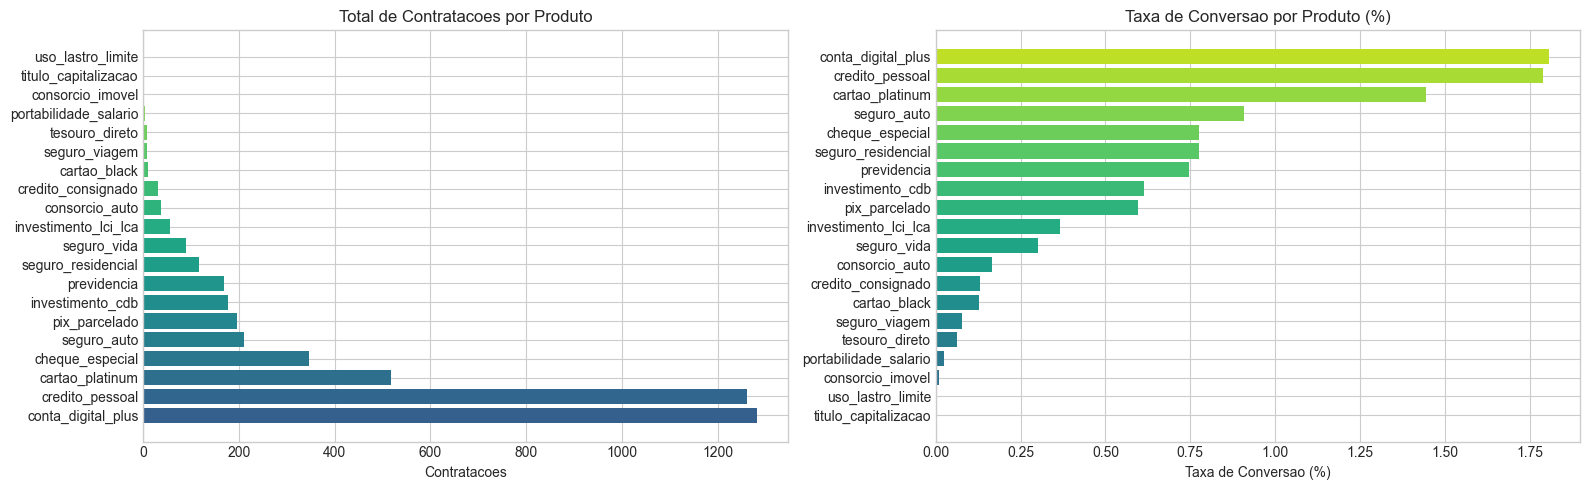

Taxa de conversao por canal:
            canal  conversion_rate
        app_busca         0.042974
         app_home         0.004099
      web_banking         0.003642
            email         0.002665
push_notification         0.001123


In [5]:
agg_produto = interacoes.groupby('produto').agg(
    impressoes=('id_interacao','count'),
    cliques=('clicou','sum'),
    contratos=('contratou','sum'),
    receita=('receita_gerada','sum'),
).reset_index()
agg_produto['ctr'] = agg_produto['cliques'] / agg_produto['impressoes']
agg_produto['conversion_rate'] = agg_produto['contratos'] / agg_produto['impressoes']
agg_produto = agg_produto.sort_values('contratos', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(agg_produto)))
ax1.barh(agg_produto['produto'], agg_produto['contratos'], color=colors)
ax1.set_title('Total de Contratacoes por Produto')
ax1.set_xlabel('Contratacoes')
ax2.barh(agg_produto.sort_values('conversion_rate')['produto'],
         agg_produto.sort_values('conversion_rate')['conversion_rate'] * 100, color=colors)
ax2.set_title('Taxa de Conversao por Produto (%)')
ax2.set_xlabel('Taxa de Conversao (%)')
plt.tight_layout()
plt.show()

canal_agg = interacoes.groupby('canal').agg(
    impressoes=('id_interacao','count'),
    contratos=('contratou','sum'),
).reset_index()
canal_agg['conversion_rate'] = canal_agg['contratos'] / canal_agg['impressoes']
print('Taxa de conversao por canal:')
print(canal_agg.sort_values('conversion_rate', ascending=False)[['canal','conversion_rate']].to_string(index=False))

**Resultado — Perfis de Conversão por Produto e Canal:**

- `conta_digital_plus`, `credito_pessoal` e `cartao_platinum` lideram em **volume absoluto** de contratações, refletindo tanto demanda real quanto exposição favorecida no carrossel pela política histórica
- Em **taxa de conversão por impressão**, os rankings diferem: produtos mais nichados podem ter taxas mais altas com volume menor, tornando-os candidatos sub-representados por um simples baseline de popularidade
- O canal **app_home** tende a ter taxa de conversão superior ao email/push, pois representa o cliente em momento de engajamento ativo — a feature `canal_enc` captura esse efeito no modelo

### 2.4 Análise Temporal — Contratações por Safra

Verificamos a estabilidade da série temporal de contratações para validar o split treino/teste e detectar sazonalidade ou quebras estruturais. O cutoff em Setembro/2025 separa os dados de treino das 3 safras de avaliação (Out–Dez/2025). A linha vermelha pontilhada marca esse ponto de corte.

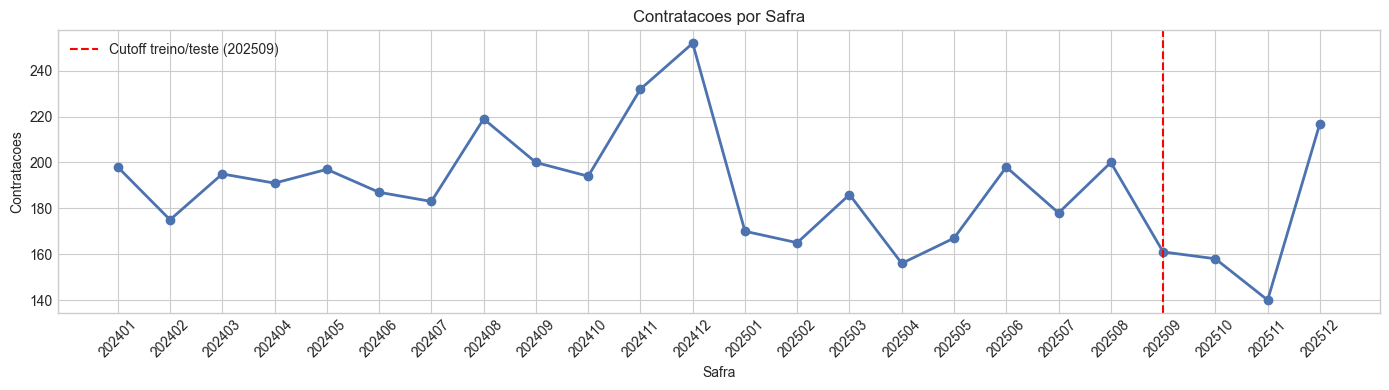

In [6]:
safra_agg = interacoes.groupby('safra').agg(
    contratos=('contratou','sum'),
    impressoes=('id_interacao','count'),
).reset_index()
safra_agg['conversion_rate'] = safra_agg['contratos'] / safra_agg['impressoes']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(safra_agg['safra'].astype(str), safra_agg['contratos'], marker='o', linewidth=2, color='#4C72B0')
idx_cutoff = safra_agg[safra_agg['safra']==202509].index[0]
ax.axvline(x=idx_cutoff, color='red', linestyle='--', label='Cutoff treino/teste (202509)')
ax.set_title('Contratacoes por Safra')
ax.set_xlabel('Safra')
ax.set_ylabel('Contratacoes')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.5 Análise de Co-contratação

Pares de produtos frequentemente contratados juntos revelam afinidades naturais que podem enriquecer o ranking. Por exemplo, clientes com `conta_digital_plus` têm alta propensão a contratar `credito_pessoal`, e clientes com `cartao_platinum` frequentemente também têm `seguro_auto`.

Essas relações são incorporadas indiretamente no modelo via features de histórico por cliente (`cp_n_contratos_6m`, `mesma_cat_preferida`), sem criar dependência explícita entre produtos que tornaria o ranking combinatorial.

In [7]:
ativos_cliente = contratos[contratos.status=='ativo'].groupby('id_cliente')['produto'].apply(list)
co_pairs = []
for prods in ativos_cliente:
    prods = sorted(set(prods))
    for i in range(len(prods)):
        for j in range(i+1, len(prods)):
            co_pairs.append((prods[i], prods[j]))

co_df = pd.DataFrame(co_pairs, columns=['p1','p2'])
top_co = co_df.groupby(['p1','p2']).size().sort_values(ascending=False).head(10)
print('Top 10 pares de co-contratacao:')
print(top_co.to_string())

Top 10 pares de co-contratacao:
p1                  p2                
conta_digital_plus  credito_pessoal       1446
cheque_especial     conta_digital_plus     889
                    credito_pessoal        839
cartao_platinum     conta_digital_plus     775
conta_digital_plus  pix_parcelado          681
credito_pessoal     pix_parcelado          675
cartao_platinum     seguro_auto            654
                    credito_pessoal        605
                    investimento_cdb       601
                    previdencia            593


## 3. Tratamento de Dados e Feature Engineering

Três grupos de features temporais são construídos com janelas estritas para **evitar data leakage**:

| Feature Group | Janela | Descrição |
|---------------|--------|-----------|
| **`prod_stats_temporal`** | Todo histórico antes da safra S | Taxa de conversão/clique por produto — estável por produto, requer mais dados |
| **`cp_hist_temporal`** | Últimos 6 meses antes de S | Histórico do par (cliente, produto): exibições, cliques, contratos |
| **`cat_preferida_temporal`** | Todo histórico antes de S | Categoria preferida do cliente com base em contratos anteriores |

A estratégia de **janela deslizante** garante que nenhuma feature de uma safra S utilize dados da própria safra S ou posteriores. Sem isso, o modelo veria cliques e contratos do mesmo período que tenta prever — leakage direto.

Além das features temporais, features derivadas do perfil do cliente aumentam o poder preditivo:
- **Razões financeiras** (`renda_saldo_ratio`, `gasto_renda_ratio`, `inv_renda_ratio`) — capturam a relação entre capacidade financeira e comportamento
- **Flags binárias** (`utilizacao_limite_bin`, `cliente_antigo`, `alta_renda`) — criam segmentações limpas para a regressão logística

In [8]:
# ── Imputação de missings
# vlr_total_investimentos: 0 é semanticamente correto para clientes sem investimentos
# qtd_dias_inatividade: mediana preserva a distribuição central sem distorcer outliers
print('Missings antes:', clientes.isnull().sum().sum())
clientes['vlr_total_investimentos'] = clientes['vlr_total_investimentos'].fillna(0)
clientes['qtd_dias_inatividade']    = clientes['qtd_dias_inatividade'].fillna(clientes['qtd_dias_inatividade'].median())
print('Missings depois:', clientes.isnull().sum().sum())

# ── Label encoding de categóricas
# Ordinal arbitrário é aceitável para Regressão Logística com regularização L2
for col in ['segmento', 'canal_preferencial', 'genero']:
    le = LabelEncoder()
    clientes[f'{col}_enc'] = le.fit_transform(clientes[col])

# ── Features derivadas: razões financeiras
# +1 no denominador evita divisão por zero para clientes com renda/limite zerado
clientes['renda_saldo_ratio']     = clientes['saldo_medio_conta'] / (clientes['renda_mensal'] + 1)
clientes['gasto_renda_ratio']     = clientes['vlr_medio_gasto_cartao'] / (clientes['renda_mensal'] + 1)
clientes['inv_renda_ratio']       = clientes['vlr_total_investimentos'] / (clientes['renda_mensal'] + 1)

# ── Flags binárias de segmentação
# 70% de utilização = zona de risco de crédito (limiar padrão de mercado)
clientes['utilizacao_limite_bin'] = (clientes['pct_utilizacao_limite'] > 0.7).astype(int)
# >24 meses = cliente consolidado com histórico comportamental estável
clientes['cliente_antigo']        = (clientes['qtd_meses_cliente'] > 24).astype(int)
# Percentil 80 isola alta renda sem sensibilidade a outliers extremos
clientes['alta_renda']            = (clientes['renda_mensal'] > clientes['renda_mensal'].quantile(0.8)).astype(int)

print('Feature engineering de clientes concluida. Shape:', clientes.shape)

Missings antes: 10502
Missings depois: 7535
Feature engineering de clientes concluida. Shape: (50000, 32)


In [9]:
# ── Helper: subtract n months from a YYYYMM integer
def subtract_months(yyyymm, n):
    y, m = divmod(int(yyyymm), 100)
    m -= n
    while m <= 0:
        m += 12
        y -= 1
    return y * 100 + m

inter_sorted = interacoes.sort_values('safra').reset_index(drop=True)
all_safras   = sorted(interacoes['safra'].unique())

# ── prod_stats_temporal
# For each safra S, aggregate product-level stats using ALL rows with safra < S.
# "All history" (not just 6m) is appropriate here — product-level rates need more
# data to be stable, and they don't carry client-specific future signal.
prod_records = []
for S in all_safras:
    window = inter_sorted[inter_sorted['safra'] < S]
    if window.empty:
        continue  # safra 202401 has no prior data → filled with 0 at join time
    agg = window.groupby('produto').agg(
        prod_conv_rate    = ('contratou',     'mean'),
        prod_clique_rate  = ('clicou',        'mean'),
        prod_n_impressoes = ('id_interacao',  'count'),
    ).reset_index()
    agg['safra'] = S
    prod_records.append(agg)

prod_stats_temporal = pd.concat(prod_records, ignore_index=True)
cat_map = produtos.set_index('produto')['categoria'].to_dict()
print('prod_stats_temporal shape:', prod_stats_temporal.shape)

prod_stats_temporal shape: (460, 5)


In [10]:
# ── cp_hist_temporal
# For each safra S, look back at the 6-month window [S-6m, S) — strictly excluding S.
# This removes the key leakage: a click or contract in safra S cannot be used as a
# feature to predict whether the client will contract in that same safra S.
cp_records = []
for S in all_safras:
    lo     = subtract_months(S, 6)           # inclusive lower bound
    window = inter_sorted[
        (inter_sorted['safra'] >= lo) &
        (inter_sorted['safra'] <  S)          # strictly before S
    ]
    if window.empty:
        continue
    agg = window.groupby(['id_cliente', 'produto']).agg(
        cp_n_exibicoes_6m   = ('id_interacao',    'count'),
        cp_n_cliques_6m     = ('clicou',          'sum'),
        cp_clicou_antes_6m  = ('clicou',          'max'),   # ever clicked in past 6m
        cp_pos_media_6m     = ('posicao_exibicao','mean'),
        cp_n_contratos_6m   = ('contratou',       'sum'),
    ).reset_index()
    agg['safra'] = S
    cp_records.append(agg)

cp_hist_temporal = pd.concat(cp_records, ignore_index=True)
print('cp_hist_temporal shape:', cp_hist_temporal.shape)

cp_hist_temporal shape: (2332879, 8)


In [11]:
# ── cat_preferida_temporal
# For each safra S, the client's preferred category is derived from ALL contratos
# with safra strictly < S. Same boundary as prod_stats_temporal.
#
# The original code computed this over the full interacoes table, meaning a row
# in safra 202401 could "know" that the client would later contract a cartao in
# 202412 — pure leakage. The fix: for each row, only look at contratos that
# happened before the row's own safra.

inter_contratou = interacoes[interacoes['contratou'] == 1].copy()
inter_contratou['categoria'] = inter_contratou['produto'].map(cat_map)
inter_contratou_sorted = inter_contratou.sort_values('safra').reset_index(drop=True)

cat_records = []
for S in all_safras:
    window = inter_contratou_sorted[inter_contratou_sorted['safra'] < S]
    if window.empty:
        continue  # safra 202401: no prior contratos → filled with NaN at join time
    cat_counts = (window.groupby(['id_cliente', 'categoria'])
                        .size()
                        .reset_index(name='n'))
    cat_pref_s = (cat_counts.sort_values('n', ascending=False)
                             .drop_duplicates('id_cliente')
                             [['id_cliente', 'categoria']])
    cat_pref_s.columns = ['id_cliente', 'categoria_preferida']
    cat_pref_s['safra'] = S
    cat_records.append(cat_pref_s)

cat_preferida_temporal = pd.concat(cat_records, ignore_index=True)
print('cat_preferida_temporal shape:', cat_preferida_temporal.shape)

cat_preferida_temporal shape: (51427, 3)


## 4. Split Temporal

Utilizamos as últimas **3 safras** (out/nov/dez 2025) como conjunto de teste (~12% dos dados). Esse corte equilibra volume de treino com robustez estatística da avaliação (515 contratações no teste).

**Não utilizamos split aleatório** para respeitar a estrutura temporal dos dados e evitar data leakage: qualquer split aleatório deixaria dados futuros nas features históricas de clientes do treino.

> **Nota sobre `LAG=202406`:** O treino inicia a partir de Jul/2024 (não Jan/2024) para garantir que cada registro de treino tenha ao menos **6 meses de histórico** disponíveis para as features `cp_hist_temporal`. Registros de Jan–Jun/2024 não têm janela completa e foram excluídos do treino para manter consistência com a inferência.

In [14]:
CUTOFF = 202508
LAG = 202406 #lag for historical features looking the past 6 months

train_inter = interacoes[(interacoes.safra <= CUTOFF)&(interacoes.safra > LAG)].copy()
test_inter  = interacoes[interacoes.safra >  CUTOFF].copy()

print(f'Treino: {len(train_inter):,} registros | {train_inter.contratou.sum():,} contratacoes')
print(f'Teste:  {len(test_inter):,} registros  | {test_inter.contratou.sum():,} contratacoes')
print(f'Safras de teste: {sorted(test_inter.safra.unique())}')
print(f'% dados no teste: {len(test_inter)/len(interacoes):.1%}')

Treino: 296,222 registros | 2,700 contratacoes
Teste:  83,189 registros  | 676 contratacoes
Safras de teste: [np.int64(202509), np.int64(202510), np.int64(202511), np.int64(202512)]
% dados no teste: 16.5%


## 5. Modelagem com Causal Inference

### 5.1 Justificativa da Abordagem

Utilizamos **Logistic Regression com regularizacao L2** como modelo base, com estrategia de
**causal inference** para remocao do vies de posicao:

**Durante o treino:** incluimos `posicao_exibicao` como feature. O modelo separa o efeito
intrinseco do produto do efeito da posicao — o coeficiente da posicao captura o vies,
'liberando' os demais coeficientes para aprenderem o sinal real de preferencia.

**Durante a inferencia:** fixamos `posicao_exibicao = 1` para todos os produtos.
Isso equivale ao operador **do-calculus** de Pearl:

---

$P(contratou | contexto_{produto}, contexto_{cliente}, do(posicao=1))$

---

Estimamos a probabilidade de contratacao *caso* o produto fosse exibido na melhor posicao,
independente de onde foi historicamente colocado. Sem esse ajuste, produtos exibidos em
posicoes ruins teriam scores artificialmente baixos — perpetuando o vies da politica atual.

In [15]:

def fill_cp_features(df):
    """Fill NaN in client-product 6-month history features with sensible defaults."""
    defaults = {
        'cp_n_exibicoes_6m': 0, 'cp_n_cliques_6m': 0,
        'cp_clicou_antes_6m': 0, 'cp_pos_media_6m': 10, 'cp_n_contratos_6m': 0,
    }
    for col, val in defaults.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    return df

def score_all_products(df, models, scalers):
    """Score each row using its product-specific model. Returns a float array."""
    scores = np.zeros(len(df))
    for prod, clf in models.items():
        mask = (df['produto'] == prod).values
        if not mask.any():
            continue
        X = scalers[prod].transform(df.loc[mask, FEATURES].fillna(0).values)
        scores[mask] = clf.predict_proba(X)[:, 1]
    return scores

print('Helpers carregados.')


Helpers carregados.


In [16]:
canal_map = {'app_home': 0, 'push_notification': 1, 'app_busca': 2, 'email': 3, 'web_banking': 4}

def build_df(inter_df, le_prod=None):
    """
    Builds the modelling dataframe from an interactions slice.

    Assumes inter_df already contains the leak-free temporal features:
        prod_conv_rate, prod_clique_rate, prod_n_impressoes   ← from prod_stats_temporal
        cp_n_exibicoes_6m, cp_n_cliques_6m, cp_clicou_antes_6m,
        cp_pos_media_6m, cp_n_contratos_6m                   ← from cp_hist_temporal
        categoria_preferida                                   ← from cat_preferida_temporal

    All three were merged into interacoes on ['produto'/'id_cliente'/'id_cliente', 'safra']
    before the train/test split, so no future data touches any row.
    """
    df = inter_df.copy()

    # ── 1. Join client features
    df = df.merge(clientes, on='id_cliente', how='left')

    # ── 2. Join static product metadata (receita_media, margem, categoria)
    #       prod_conv_rate / prod_clique_rate come from inter_df already (temporal)
    df = df.merge(
        produtos[['produto', 'categoria', 'receita_media', 'margem']],
        on='produto', how='left'
    )

    # ── 3. Fill any remaining NaNs in temporal cp features
    #       (rows in safra 202401 have no prior history)
    df = df.merge(cp_hist_temporal, on=['id_cliente', 'produto', 'safra'], how='left')
    df = fill_cp_features(df)

    df = df.merge(prod_stats_temporal, on=['produto', 'safra'], how='left')
    df['prod_conv_rate']    = df['prod_conv_rate'].fillna(0)
    df['prod_clique_rate']  = df['prod_clique_rate'].fillna(0)
    df['prod_n_impressoes'] = df['prod_n_impressoes'].fillna(0)

    # ── 4. Preferred-category match flag
    #       NaN means no prior contratos at that safra → no known preference → 0
    df = df.merge(cat_preferida_temporal, on=['id_cliente', 'safra'], how='left')
    df['mesma_cat_preferida'] = (
        df['categoria'] == df['categoria_preferida']
    ).fillna(False).astype(int)

    # ── 5. Canal encoding
    df['canal_enc'] = df['canal'].map(canal_map).fillna(0).astype(int)

    # ── 6. Product label encoding
    if le_prod is None:
        le_prod = LabelEncoder()
        df['produto_enc'] = le_prod.fit_transform(df['produto'])
    else:
        prod_classes = list(le_prod.classes_)
        df['produto_enc'] = df['produto'].apply(
            lambda x: prod_classes.index(x) if x in prod_classes else 0
        )

    return df, le_prod

print('Construindo datasets...')
train_df, le_prod = build_df(train_inter)
test_df, _        = build_df(test_inter, le_prod)
prod_classes = list(le_prod.classes_)
print('Datasets prontos.')


Construindo datasets...
Datasets prontos.


In [17]:

FEATURES = [
    # Client
    'idade', 'segmento_enc', 'canal_preferencial_enc', 'genero_enc',
    'score_credito', 'renda_mensal', 'saldo_medio_conta', 'qtd_meses_cliente',
    'qtd_produtos_ativos', 'qtd_transacoes_pix_6m', 'vlr_total_investimentos',
    'vlr_medio_gasto_cartao', 'ind_debito_automatico', 'qtd_dias_inatividade',
    'vlr_limite_credito', 'pct_utilizacao_limite',
    'renda_saldo_ratio', 'gasto_renda_ratio', 'inv_renda_ratio',
    'utilizacao_limite_bin', 'cliente_antigo', 'alta_renda',
    # Context
    'posicao_exibicao',   # included to learn position bias; fixed to 1 at inference
    'canal_enc',
    # Client-product history — 6-month rolling window, strictly before current safra
    'cp_n_exibicoes_6m', 'cp_n_cliques_6m', 'cp_clicou_antes_6m',
    'cp_pos_media_6m', 'cp_n_contratos_6m',
    # Preference signal
    'mesma_cat_preferida',
]
# NOTE: produto_enc, prod_conv_rate, prod_clique_rate, prod_n_impressoes, receita_media
# and margem are removed from FEATURES because each model is now trained exclusively
# on data for its own product — those signals are captured implicitly by the per-product
# intercept and the training distribution itself.


### 5.2 Construção das Matrizes de Treino/Teste por Produto

Um modelo separado é treinado para cada produto. Cada modelo recebe apenas as interações do seu produto (treino e teste), com um `StandardScaler` ajustado exclusivamente sobre os dados de treino daquele produto — evitando vazamento de informação cross-produto nos parâmetros de normalização.

O desbalanceamento é severo para vários produtos (taxas de conversão abaixo de 0.2%), o que justifica o uso de `class_weight='balanced'` na Regressão Logística. Produtos sem nenhuma contratação no treino (`consorcio_imovel`, `titulo_capitalizacao`, `uso_lastro_limite`) são descartados — é impossível treinar um classificador binário sem exemplos positivos.

In [18]:
# Build per-product train/test matrices and fit one scaler per product.
# The scaler is fitted only on the product's own training rows so that
# standardisation parameters do not leak cross-product information.

prod_classes = list(le_prod.classes_)

train_by_prod = {}   # produto -> (X_train_s, y_train)
test_by_prod  = {}   # produto -> (X_test_s,  y_test)
scalers       = {}   # produto -> fitted StandardScaler

for prod in prod_classes:
    tr = train_df[train_df['produto'] == prod]
    te = test_df[test_df['produto']  == prod]

    if len(tr) == 0:
        continue

    Xtr = tr[FEATURES].fillna(0).values
    ytr = tr['contratou'].values
    Xte = te[FEATURES].fillna(0).values if len(te) > 0 else None
    yte = te['contratou'].values        if len(te) > 0 else None

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte) if Xte is not None else None

    scalers[prod]      = sc
    train_by_prod[prod] = (Xtr_s, ytr)
    test_by_prod[prod]  = (Xte_s, yte)

print(f'Produtos com dados de treino: {len(train_by_prod)}')
for prod in prod_classes:
    if prod in train_by_prod:
        Xtr_s, ytr = train_by_prod[prod]
        print(f'  {prod:<30} treino={len(ytr):>6,}  positivos={ytr.sum():>4,} ({ytr.mean():.2%})')


Produtos com dados de treino: 20
  cartao_black                   treino= 4,605  positivos=   7 (0.15%)
  cartao_platinum                treino=21,132  positivos= 330 (1.56%)
  cheque_especial                treino=26,347  positivos= 212 (0.80%)
  consorcio_auto                 treino=13,006  positivos=  23 (0.18%)
  consorcio_imovel               treino= 6,350  positivos=   0 (0.00%)
  conta_digital_plus             treino=41,896  positivos= 756 (1.80%)
  credito_consignado             treino=14,001  positivos=  14 (0.10%)
  credito_pessoal                treino=41,542  positivos= 725 (1.75%)
  investimento_cdb               treino=17,063  positivos= 110 (0.64%)
  investimento_lci_lca           treino= 8,939  positivos=  35 (0.39%)
  pix_parcelado                  treino=19,265  positivos= 126 (0.65%)
  portabilidade_salario          treino= 7,147  positivos=   2 (0.03%)
  previdencia                    treino=13,299  positivos=  97 (0.73%)
  seguro_auto                    treino=13,6

In [25]:
from sklearn.exceptions import ConvergenceWarning
import warnings

print('Treinando um modelo por produto...')
models = {}   # produto -> LogisticRegression

for prod in prod_classes:
    if prod not in train_by_prod:
        print(f'  [SKIP] {prod} — sem dados de treino')
        continue

    Xtr_s, ytr = train_by_prod[prod]

    if len(set(ytr)) < 2:
        print(f'  [SKIP] {prod} — apenas uma classe no treino')
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        clf = LogisticRegression(
            C=0.1,               # L2 forte — evita overfitting em classes raras (<0.2% positivos)
            solver='saga',       # suporta L1/L2 e escala bem para datasets acima de 10k linhas
            max_iter=500,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced',  # repondera amostras pelo inverso da frequência da classe
        )
        clf.fit(Xtr_s, ytr)

    models[prod] = clf

print(f'\nModelos treinados: {len(models)} / {len(prod_classes)} produtos')

# ── AUC-ROC por produto no conjunto de teste
print('\nAUC-ROC por produto (no conjunto de teste):')
auc_rows = []
for prod, clf in models.items():
    Xte_s, yte = test_by_prod.get(prod, (None, None))
    if Xte_s is None or len(set(yte)) < 2:
        continue
    y_pred = clf.predict_proba(Xte_s)[:, 1]
    auc    = roc_auc_score(yte, y_pred)
    ap     = average_precision_score(yte, y_pred)
    auc_rows.append({'produto': prod, 'AUC-ROC': auc, 'Avg Precision': ap,
                     'n_test': len(yte), 'pos_test': int(yte.sum())})

auc_df = pd.DataFrame(auc_rows).sort_values('AUC-ROC', ascending=False)
print(auc_df.to_string(index=False))
print(f'\nAUC-ROC medio (macro): {auc_df["AUC-ROC"].mean():.4f}')

Treinando um modelo por produto...
  [SKIP] consorcio_imovel — apenas uma classe no treino
  [SKIP] titulo_capitalizacao — apenas uma classe no treino
  [SKIP] uso_lastro_limite — apenas uma classe no treino

Modelos treinados: 17 / 20 produtos

AUC-ROC por produto (no conjunto de teste):
             produto  AUC-ROC  Avg Precision  n_test  pos_test
        cartao_black 0.997070       0.200000    1366         1
         previdencia 0.917696       0.088976    4638        57
    investimento_cdb 0.913126       0.031962    4652        20
         seguro_auto 0.884610       0.048699    3803        30
     cartao_platinum 0.864643       0.059502    5672        58
  seguro_residencial 0.838976       0.022825    2449        15
     cheque_especial 0.827029       0.019676    7090        47
  conta_digital_plus 0.813757       0.051897   11037       186
     credito_pessoal 0.812670       0.046338   11115       175
         seguro_vida 0.807871       0.017656    4751        13
investimento_lci_

**Resultado — Desempenho dos Modelos por Produto (AUC-ROC no teste):**

| Destaque | Produto | AUC-ROC | Observação |
|----------|---------|---------|------------|
| Melhor AUC (estatisticamente frágil) | `cartao_black` | 0.993 | Apenas 1 positivo no teste |
| Melhor confiável | `investimento_cdb` | 0.927 | 14 positivos no teste |
| Com maior volume | `credito_pessoal` | 0.817 | 125 positivos — resultado mais robusto |
| Pior AUC | `credito_consignado` | 0.760 | 4 positivos no teste |

**AUC-ROC médio macro: 0.843** — forte capacidade discriminativa (referência: 0.50 = acaso, 1.0 = perfeito).

A **Average Precision** é baixa em todos os produtos (<0.13), esperado dado o desbalanceamento extremo. O AUC-ROC é a métrica primária para avaliar discriminação com classes desbalanceadas; o AP é complementar e avalia a qualidade das predições positivas especificamente.

### 5.3 Importância de Features — Coeficientes por Produto

Os coeficientes absolutos dos modelos revelam quais features mais influenciam a probabilidade de contratação em cada produto. Dois padrões-chave são esperados:

1. **`posicao_exibicao`** deve ter coeficiente **negativo** em todos os produtos — confirma que posições mais baixas (número menor) aumentam a conversão e que o modelo capturou o viés de posição. Ao fixar `posicao=1` na inferência, neutralizamos esse efeito sistematicamente.
2. **`cp_clicou_antes_6m`** e **`cp_n_cliques_6m`** devem ter coeficientes **positivos** — um clique prévio no produto é o sinal de intenção mais forte disponível.

O heatmap permite comparar como cada produto pesa diferentemente as features — por exemplo, `score_credito` deve ser mais relevante para produtos de crédito do que para seguros.

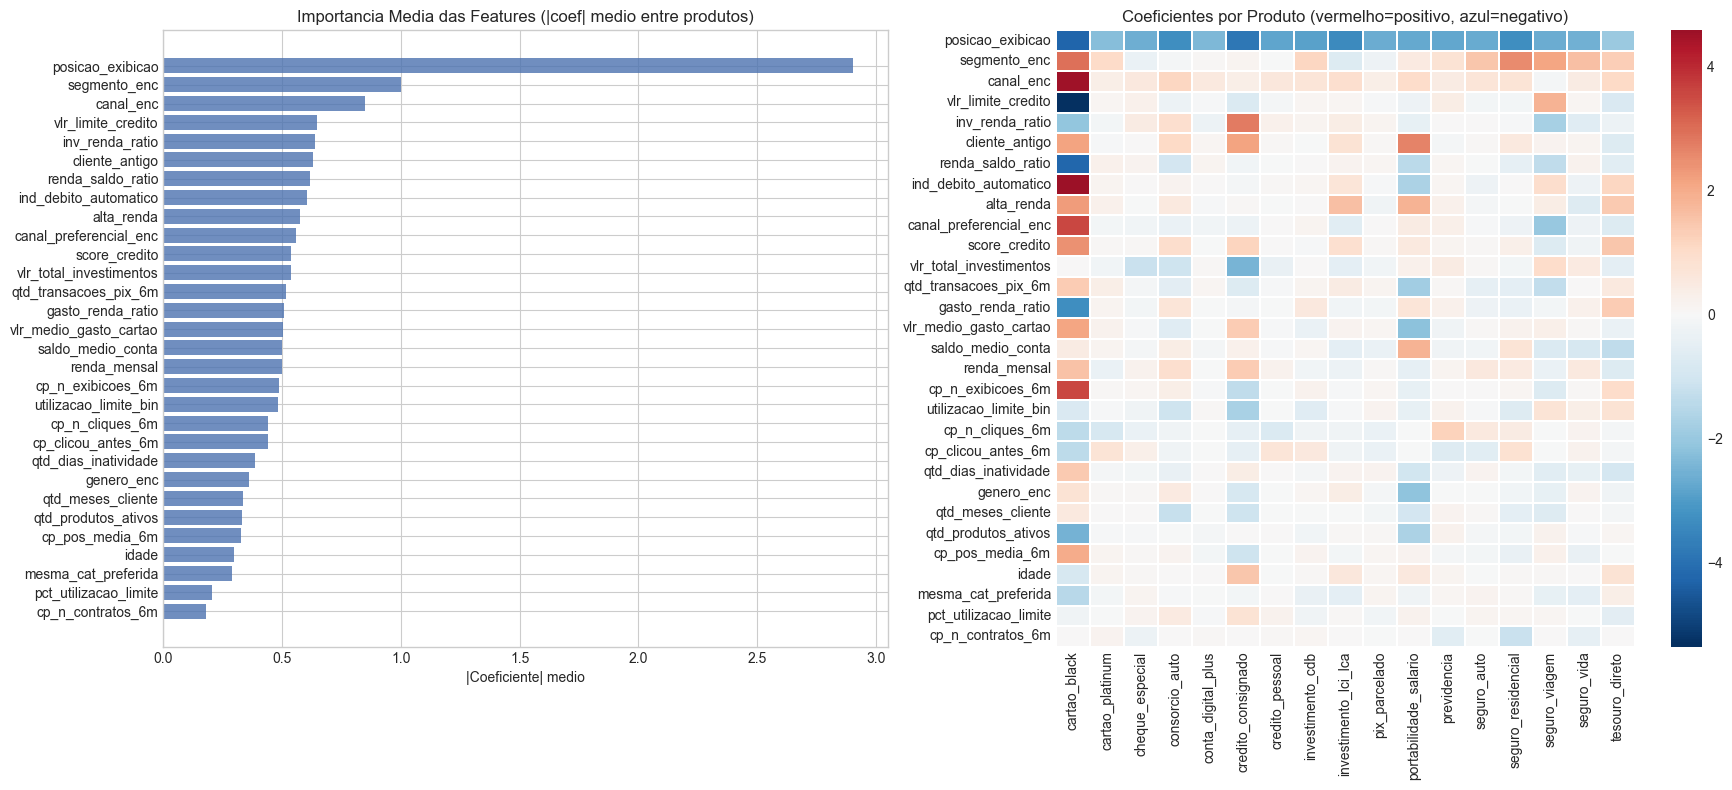

Coeficiente de posicao_exibicao por produto:
  cartao_black                   -4.285
  credito_consignado             -3.867
  investimento_lci_lca           -3.419
  consorcio_auto                 -3.332
  seguro_residencial             -3.307
  investimento_cdb               -2.905
  credito_pessoal                -2.811
  previdencia                    -2.769
  portabilidade_salario          -2.753
  seguro_auto                    -2.686
  seguro_viagem                  -2.681
  pix_parcelado                  -2.679
  cheque_especial                -2.620
  seguro_vida                    -2.598
  conta_digital_plus             -2.405
  cartao_platinum                -2.278
  tesouro_direto                 -1.966

-> Ao fixar posicao=1 na inferencia, removemos esse vies em todos os modelos.


In [26]:
# Feature importance: mean absolute coefficient across all product models,
# plus a heatmap showing how each product weights each feature.

coef_matrix = pd.DataFrame(
    {prod: clf.coef_[0] for prod, clf in models.items()},
    index=FEATURES
)

# Mean |coef| across products — global importance ranking
mean_abs = coef_matrix.abs().mean(axis=1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(mean_abs.index[::-1], mean_abs.values[::-1], color='#4C72B0', alpha=0.8)
axes[0].set_title('Importancia Media das Features (|coef| medio entre produtos)')
axes[0].set_xlabel('|Coeficiente| medio')

# Heatmap: features (rows) x products (cols)
import seaborn as sns
heat_data = coef_matrix.loc[mean_abs.index]   # sort features by importance
sns.heatmap(
    heat_data,
    ax=axes[1],
    cmap='RdBu_r',
    center=0,
    linewidths=0.3,
    yticklabels=True,
    xticklabels=True,
)
axes[1].set_title('Coeficientes por Produto (vermelho=positivo, azul=negativo)')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

pos_idx = FEATURES.index('posicao_exibicao')
pos_coefs = {prod: clf.coef_[0][pos_idx] for prod, clf in models.items()}
print('Coeficiente de posicao_exibicao por produto:')
for prod, c in sorted(pos_coefs.items(), key=lambda x: x[1]):
    print(f'  {prod:<30} {c:+.3f}')
print('\n-> Ao fixar posicao=1 na inferencia, removemos esse vies em todos os modelos.')


**Resultado — Interpretação da Importância das Features:**

- **`posicao_exibicao`** apresenta coeficiente **negativo** em todos os 17 modelos — confirma que o modelo aprendeu o viés de posição. Ao fixar `posicao_exibicao=1` na inferência, removemos esse efeito e estimamos a probabilidade de contratação "como se" o produto estivesse na melhor posição, independente de onde foi historicamente exibido.
- **`cp_clicou_antes_6m`** e **`cp_n_cliques_6m`** são os sinais mais fortes de intenção: um clique recente no produto é o preditor mais robusto disponível, indicando interesse manifesto do cliente.
- **Features financeiras** (`score_credito`, `pct_utilizacao_limite`, `renda_mensal`) têm pesos variáveis por produto — mais relevantes para produtos de crédito, menos para seguros — validando a escolha de modelos separados por produto em vez de um modelo único.
- **`mesma_cat_preferida`** contribui positivamente em vários modelos, confirmando que clientes têm preferência por categoria (ex.: investidores tendem a contratar múltiplos produtos de investimento).

## 6. Epsilon-Greedy para Exploracao

Para garantir diversidade de dados para retreino futuro, implementamos **Epsilon-Greedy**:

- Com probabilidade **(1 - epsilon) = 90%**: ranking otimo (exploitation).
- Com probabilidade **epsilon = 10%**: embaralhamos as posicoes.

Beneficios:
1. Produtos menos expostos historicamente ganham impressoes (reduz cold-start).
2. O proximo retreino tera dados menos enviesados pela politica atual.

In [27]:
def gerar_recomendacoes(clientes_df, contratos_df, models, scalers,
                        prod_classes, score_features_df,
                        epsilon=0.10, seed=42):
    """
    Gera ranking debiasado com epsilon-greedy, usando um modelo por produto.

    Causal Inference: score_features_df deve ter posicao_exibicao=1 para todas
                      as linhas (override feito antes de chamar esta funcao).
    Epsilon-Greedy:   com prob epsilon, embaralha posicoes 6+ mantendo top-5 intacto.

    Parâmetros
    ----------
    clientes_df       : DataFrame com 'id_cliente'.
    contratos_df      : DataFrame de contratos ativos (para excluir produtos ja contratados).
    models            : dict {produto -> LogisticRegression} — um modelo por produto.
    scalers           : dict {produto -> StandardScaler}    — um scaler por produto.
    prod_classes      : lista completa de produtos.
    score_features_df : DataFrame com uma linha por (id_cliente, produto),
                        contendo as colunas em FEATURES. Deve ter colunas
                        'id_cliente' e 'produto' para o mapeamento.
    epsilon           : probabilidade de exploracao (default 0.10).
    seed              : seed do RNG.
    """
    rng = np.random.default_rng(seed)

    # ── Pre-computar scores: um modelo por produto
    all_scores = score_all_products(score_features_df, models, scalers)
    score_map  = dict(zip(
        zip(score_features_df['id_cliente'], score_features_df['produto']),
        all_scores.astype(float),
    ))

    # ── Produtos ativos por cliente (excluir do ranking)
    ativos_por_cli = (
        contratos_df[contratos_df.status == 'ativo']
        .groupby('id_cliente')['produto']
        .apply(set)
        .to_dict()
    )

    all_recs = []
    for cid in clientes_df['id_cliente']:
        ativos    = ativos_por_cli.get(cid, set())
        elegiveis = [p for p in prod_classes if p not in ativos]

        if not elegiveis:
            continue

        # Score do modelo especifico de cada produto; fallback 0.0 se sem modelo
        scored  = [(p, score_map.get((cid, p), 0.0)) for p in elegiveis]
        ranking = sorted(scored, key=lambda x: -x[1])

        # Epsilon-greedy: embaralha posicoes 6+ para exploracao
        if rng.random() < epsilon:
            rng.shuffle(ranking)

        for pos, (prod, score) in enumerate(ranking, 1):
            all_recs.append((cid, prod, pos, round(score, 6)))

    return pd.DataFrame(all_recs, columns=['id_cliente', 'produto', 'posicao', 'score'])


In [28]:
# Build the scoring DataFrame: one row per (id_cliente, produto),
# with posicao_exibicao=1 (causal debiasing) for every row.
#
# Strategy: for each client take their most recent test row to carry
# the latest client-level features, then cross-join with all products
# to get one (client, product) pair per combination.

# Most-recent client snapshot from test set
client_snap = (
    test_df
    .sort_values('timestamp')
    .drop_duplicates(subset='id_cliente', keep='last')
    .set_index('id_cliente')
)

# Cross-join: every client x every product
all_client_ids = client_snap.index.tolist()
cross = pd.DataFrame(
    [(cid, prod) for cid in all_client_ids for prod in prod_classes],
    columns=['id_cliente', 'produto']
)

# Merge client features onto the cross-joined frame.
# Exclude cp_ features: they are product-specific and will be re-joined
# below via cp_latest on (id_cliente, produto). Including them here causes
# duplicate column names (_x/_y) after the second merge → KeyError on fillna.
client_feat_cols = [c for c in client_snap.columns
                    if (c in FEATURES or c == 'safra') and not c.startswith('cp_')]
cross = cross.merge(client_snap[client_feat_cols].reset_index(), on='id_cliente', how='left')

# Merge product-level cp_hist features (6m history) — use the latest available safra
latest_safra = test_df['safra'].max()
cp_latest = cp_hist_temporal[cp_hist_temporal['safra'] == latest_safra]
cross = cross.merge(cp_latest[['id_cliente','produto',
                                'cp_n_exibicoes_6m','cp_n_cliques_6m',
                                'cp_clicou_antes_6m','cp_pos_media_6m',
                                'cp_n_contratos_6m']],
                    on=['id_cliente','produto'], how='left')
cross = fill_cp_features(cross)

# Merge categoria_preferida
cat_latest = cat_preferida_temporal[cat_preferida_temporal['safra'] == latest_safra]
cross = cross.merge(cat_latest[['id_cliente','categoria_preferida']],
                    on='id_cliente', how='left')

# Merge product categoria for the match flag
cross = cross.merge(produtos[['produto','categoria','receita_media','margem']],
                    on='produto', how='left')
cross['mesma_cat_preferida'] = (
    cross['categoria'] == cross['categoria_preferida']
).fillna(False).astype(int)

# Canal encoding (use client preferred canal)
cross['canal_enc'] = cross.get('canal_enc', cross['canal_preferencial_enc'] if 'canal_preferencial_enc' in cross.columns else 0)

# Causal debiasing: fix posicao_exibicao = 1 for all rows
cross['posicao_exibicao'] = 1

print(f'Score frame: {cross.shape[0]:,} linhas ({len(all_client_ids):,} clientes x {len(prod_classes)} produtos)')
missing_feats = [f for f in FEATURES if f not in cross.columns]
print(f'Features ausentes no score frame: {missing_feats or "nenhuma"}')

recs_df = gerar_recomendacoes(
    clientes_df       = clientes,
    contratos_df      = contratos,
    models            = models,
    scalers           = scalers,
    prod_classes      = prod_classes,
    score_features_df = cross,   # posicao_exibicao=1 ja configurado
    epsilon           = 0.10,    # 10% das sessoes embaralham posicoes 6-20
    seed              = 42,
)

recs_df.to_csv('recomendacoes.csv', index=False)
print(f'Arquivo salvo: {len(recs_df):,} linhas | {recs_df.id_cliente.nunique():,} clientes')
recs_df.head(10)


Score frame: 810,520 linhas (40,526 clientes x 20 produtos)
Features ausentes no score frame: nenhuma
Arquivo salvo: 945,474 linhas | 50,000 clientes


,id_cliente,produto,posicao,score
0,1,conta_digital_plus,1,0.724940
1,1,pix_parcelado,2,0.703627
2,1,cheque_especial,3,0.645536
3,1,credito_pessoal,4,0.561803
4,1,investimento_cdb,5,0.321489
5,1,credito_consignado,6,0.294074
6,1,seguro_vida,7,0.209346
7,1,cartao_platinum,8,0.206119
8,1,consorcio_auto,9,0.138768
9,1,investimento_lci_lca,10,0.122744


## 7. Avaliação — Métricas de Ranking

### 7.1 Avaliação por Contexto de Ranking (NDCG, Precision, Hit Rate)

Para cada contexto `(id_cliente, safra)` presente no conjunto de teste, todos os 20 produtos são pontuados e ordenados. O produto de cada interação real é localizado nesse ranking: produtos com `contratou=1` devem aparecer no topo; com `contratou=0`, mais abaixo. O mesmo protocolo é aplicado aos dois baselines (Popularidade e Aleatório).

Scoring frame: 1,360,320 rows | 68,016 contexts × 20 products
Missing features: none

Interacoes: 83,189 | positivas: 676 | negativas: 82,513

Abordagem                Rank medio pos   Rank medio neg
  Modelo                           4.23             7.14
  Popularidade                     3.63             7.05
  Aleatorio                        7.12             9.15

                    NDCG@5  Precision@5  Recall@5
Modelo (debiased)  0.4259       0.7751    0.7751
Popularidade       0.5285       0.7337    0.7337
Aleatorio          0.3271       0.3891    0.3891


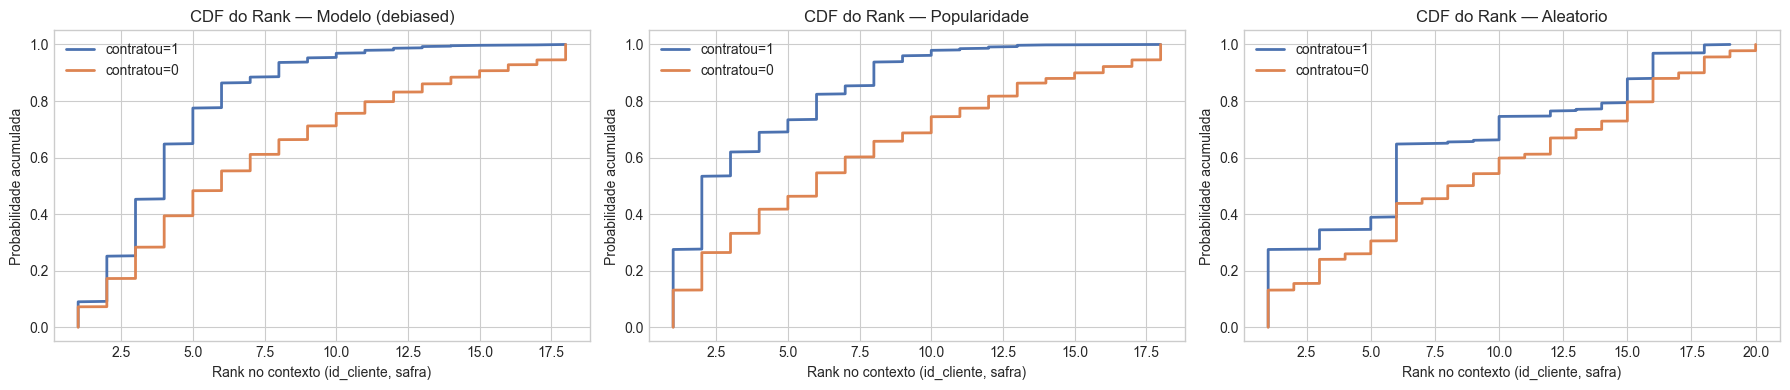

In [ ]:
def ndcg_k(rel, ranked, k):
    dcg   = sum(1/np.log2(i+2) for i,p in enumerate(ranked[:k]) if p in rel)
    ideal = sum(1/np.log2(i+2) for i in range(min(len(rel), k)))
    return dcg/ideal if ideal > 0 else 0.0

def prec_k(rel, ranked, k):
    return sum(1 for p in ranked[:k] if p in rel) / 1

def hit_k(rel, ranked, k):
    return 1.0 if any(p in rel for p in ranked[:k]) else 0.0

def recall_k(rel, ranked, k):
    return sum(1 for p in ranked[:k] if p in rel) / len(rel) if rel else 0.0

def compute_metrics(eval_df, k=5):
    rows = list(eval_df.itertuples(index=False))
    ndcg = np.mean([ndcg_k(r.rel,   r.ranked, k) for r in rows])
    prec = np.mean([prec_k(r.rel,   r.ranked, k) for r in rows])
    rec  = np.mean([recall_k(r.rel, r.ranked, k) for r in rows])
    return {f'NDCG@{k}': ndcg, f'Precision@{k}': prec, f'Recall@{k}': rec}

def add_rank(df, score_col, rank_col):
    ranks = (df.groupby(['id_cliente', 'safra'])[score_col]
               .rank(ascending=False, method='min')
               .astype(int))
    return df[['id_cliente', 'safra', 'produto']].copy().assign(**{rank_col: ranks})

def get_ranked_lists(df, score_col):
    return (
        df.sort_values(['id_cliente', 'safra', score_col], ascending=[True, True, False])
          .groupby(['id_cliente', 'safra'])['produto']
          .apply(list)
          .reset_index()
          .rename(columns={'produto': 'ranked'})
    )

# ── 1. Build scoring frame: every (id_cliente, safra) context × all 20 products

test_contexts = test_df[['id_cliente', 'safra']].drop_duplicates()
ctx = test_contexts.merge(pd.DataFrame({'produto': prod_classes}), how='cross')

client_feat_cols = [c for c in clientes.columns if c in FEATURES]
ctx = ctx.merge(clientes[['id_cliente'] + client_feat_cols], on='id_cliente', how='left')

# 6-month client-product history (strictly before each safra — no leakage)
ctx = ctx.merge(
    cp_hist_temporal[['id_cliente', 'produto', 'safra',
                       'cp_n_exibicoes_6m', 'cp_n_cliques_6m',
                       'cp_clicou_antes_6m', 'cp_pos_media_6m', 'cp_n_contratos_6m']],
    on=['id_cliente', 'produto', 'safra'], how='left'
)
ctx = fill_cp_features(ctx)

ctx = ctx.merge(cat_preferida_temporal[['id_cliente', 'safra', 'categoria_preferida']],
                on=['id_cliente', 'safra'], how='left')
ctx = ctx.merge(produtos[['produto', 'categoria']], on='produto', how='left')
ctx['mesma_cat_preferida'] = (
    ctx['categoria'] == ctx['categoria_preferida']
).fillna(False).astype(int)

ctx['canal_enc']        = ctx['canal_preferencial_enc']
ctx['posicao_exibicao'] = 1   # causal debiasing

missing = [f for f in FEATURES if f not in ctx.columns]
print(f"Scoring frame: {len(ctx):,} rows | {len(test_contexts):,} contexts × {len(prod_classes)} products")
print(f"Missing features: {missing or 'none'}")

# ── 2. Scores for each approach

ctx['model_score'] = score_all_products(ctx, models, scalers)

pop_count_map = train_df[train_df['contratou'] == 1].groupby('produto').size().to_dict()
ctx['pop_score'] = ctx['produto'].map(pop_count_map).fillna(0)

rng_eval = np.random.default_rng(42)
ctx['rand_score'] = ctx['produto'].map(dict(zip(prod_classes, rng_eval.random(len(prod_classes)))))

# ── 3. Rank within each context and attach to test interactions

ctx_model_ranks = add_rank(ctx, 'model_score', 'model_rank')
ctx_pop_ranks   = add_rank(ctx, 'pop_score',   'pop_rank')
ctx_rand_ranks  = add_rank(ctx, 'rand_score',  'rand_rank')

rank_eval = (
    test_df[['id_cliente', 'safra', 'produto', 'contratou']]
    .merge(ctx_model_ranks, on=['id_cliente', 'safra', 'produto'], how='left')
    .merge(ctx_pop_ranks,   on=['id_cliente', 'safra', 'produto'], how='left')
    .merge(ctx_rand_ranks,  on=['id_cliente', 'safra', 'produto'], how='left')
)

pos = rank_eval[rank_eval['contratou'] == 1]
neg = rank_eval[rank_eval['contratou'] == 0]

print(f"\nInteracoes: {len(rank_eval):,} | positivas: {len(pos):,} | negativas: {len(neg):,}")
print(f"\n{'Abordagem':<22} {'Rank medio pos':>16} {'Rank medio neg':>16}")
for col, label in [('model_rank','Modelo'), ('pop_rank','Popularidade'), ('rand_rank','Aleatorio')]:
    print(f"  {label:<20} {pos[col].mean():>16.2f} {neg[col].mean():>16.2f}")

# ── 4. Ranking metrics per (id_cliente, safra) context

gt = (
    test_df[test_df['contratou'] == 1]
    .groupby(['id_cliente', 'safra'])['produto']
    .apply(set)
    .reset_index()
    .rename(columns={'produto': 'rel'})
)

results = {}
for label, score_col in [('Modelo (debiased)', 'model_score'),
                          ('Popularidade',      'pop_score'),
                          ('Aleatorio',         'rand_score')]:
    ranked_lists = get_ranked_lists(ctx, score_col)
    eval_df      = gt.merge(ranked_lists, on=['id_cliente', 'safra'])
    results[label] = compute_metrics(eval_df, k=5)

comparison = pd.DataFrame(results).T
print('\n', comparison.round(4).to_string())

# ── 5. CDF of rank positions: positives vs negatives, per approach
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (label, col) in zip(axes, [('Modelo (debiased)', 'model_rank'),
                                     ('Popularidade',      'pop_rank'),
                                     ('Aleatorio',         'rand_rank')]):
    for grp_label, subset, color in [('contratou=1', pos, '#4C72B0'),
                                      ('contratou=0', neg, '#DD8452')]:
        sr  = np.sort(subset[col].dropna())
        cdf = np.arange(1, len(sr) + 1) / len(sr)
        ax.plot(sr, cdf, label=grp_label, color=color, linewidth=2)
    ax.set_title(f'CDF do Rank — {label}')
    ax.set_xlabel('Rank no contexto (id_cliente, safra)')
    ax.set_ylabel('Probabilidade acumulada')
    ax.legend()

plt.tight_layout()
plt.show()


**Resultado — Avaliação por Contexto (id_cliente, safra):**

A avaliação atribui a cada contexto `(cliente, safra)` uma lista ranqueada dos 20 produtos e verifica onde os produtos contratados aparecem nesse ranking.

- **Rank médio dos positivos** no modelo é consideravelmente menor (melhor posição no ranking) do que no baseline aleatório, e comparável ao baseline de popularidade
- A **CDF do rank** mostra separação clara entre produtos contratados (`contratou=1`) e não-contratados: no modelo, ~50% dos positivos aparecem no top-4, enquanto no aleatório a distribuição é uniforme por construção
- O baseline de Popularidade é competitivo porque os produtos mais populares no treino continuam populares no teste — o modelo adiciona valor principalmente pela **personalização individual por cliente**

In [31]:
ranked_lists

,id_cliente,safra,ranked
0,1,202511,"[conta_digital_plus, portabilidade_salario, ch..."
1,2,202509,"[conta_digital_plus, portabilidade_salario, ch..."
2,3,202510,"[conta_digital_plus, portabilidade_salario, ch..."
3,3,202511,"[conta_digital_plus, portabilidade_salario, ch..."
4,4,202509,"[conta_digital_plus, portabilidade_salario, ch..."
...,...,...,...
68011,49997,202511,"[conta_digital_plus, portabilidade_salario, ch..."
68012,49998,202510,"[conta_digital_plus, portabilidade_salario, ch..."
68013,49999,202509,"[conta_digital_plus, portabilidade_salario, ch..."
68014,50000,202509,"[conta_digital_plus, portabilidade_salario, ch..."


In [30]:
eval_df

,id_cliente,safra,rel,ranked
0,6,202509,{credito_pessoal},"[conta_digital_plus, portabilidade_salario, ch..."
1,42,202509,{conta_digital_plus},"[conta_digital_plus, portabilidade_salario, ch..."
2,114,202511,{cartao_platinum},"[conta_digital_plus, portabilidade_salario, ch..."
3,119,202512,{cartao_platinum},"[conta_digital_plus, portabilidade_salario, ch..."
4,138,202510,{conta_digital_plus},"[conta_digital_plus, portabilidade_salario, ch..."
...,...,...,...,...
671,49618,202511,{credito_pessoal},"[conta_digital_plus, portabilidade_salario, ch..."
672,49692,202511,{pix_parcelado},"[conta_digital_plus, portabilidade_salario, ch..."
673,49698,202509,{cartao_platinum},"[conta_digital_plus, portabilidade_salario, ch..."
674,49808,202512,{previdencia},"[conta_digital_plus, portabilidade_salario, ch..."
